# **Combinatorial MABs**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx # we will use it for visualization
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.optimize import milp
from scipy import optimize
from scipy.sparse.csgraph import shortest_path

## Weighted Matching Problem 

#### We have $S$ workers to allocate among $Q$ tasks.
#### If we assign worker $i$ to task $j$, we obtain reward $w_{i,j}$. 
#### This problem can be represented as a bipartite weighted graph (V,E).
#### We want to solve:
#### $$ \begin{aligned} \max_{M \subseteq E} \quad & \sum_{(i,j)\in M} w_{i,j} \\ \text{s.t.} \quad & M \text{ is a valid matching} \end{aligned} $$

In [ ]:
def plot_weighted_bipartite(W, with_weights=True, include_negative=False):
    B = nx.Graph()
    # Add nodes with the node attribute "bipartite"
    B.add_nodes_from(np.arange(W.shape[0]), bipartite=0)
    task_labels = [str(i) for i in range(W.shape[1])] # do not repeat labels
    B.add_nodes_from(task_labels, bipartite=1)
    # Add edges only between nodes of opposite node sets
    for (i, j), w in np.ndenumerate(W):
        if w > 0  or (w < 0 and include_negative):
            B.add_edge(i, task_labels[j], weight=w)
    pos = nx.drawing.layout.bipartite_layout(B, np.arange(W.shape[0]))
    nx.draw_networkx(B,
                     pos = pos, 
                     width = 2,
                     with_labels = True) 
    if with_weights:
        edge_labels = nx.get_edge_attributes(B, "weight")
        nx.draw_networkx_edge_labels(B, pos, edge_labels)

def plot_weighted_matching(matching, W, with_non_positive=False):
    # matching can be a list of edges or a matrix from that list
    B = nx.Graph()
    # Add nodes with the node attribute "bipartite"
    B.add_nodes_from(np.arange(W.shape[0]), bipartite=0)
    task_labels = [str(i) for i in range(W.shape[1])] # do not repeat labels
    B.add_nodes_from(task_labels, bipartite=1)
    # Add edges only between nodes of opposite node sets
    for e in matching:
        i,j = e
        if with_non_positive or W[i,j] > 0:
            B.add_edge(i, task_labels[j], weight=W[i,j])
    pos = nx.drawing.layout.bipartite_layout(B, np.arange(W.shape[0]))
    nx.draw_networkx(B,
                     pos = pos, 
                     width = 2,
                     with_labels = True) 
    edge_labels = nx.get_edge_attributes(B, "weight")
    nx.draw_networkx_edge_labels(B, pos, edge_labels)

#### Quick recap of matching terminology:
- #### Matching: a subset  of edges such that no two edges share a common vertex
- #### Maximal matching: a matching that cannot be enlarged
- #### Maximum matching: a matching with the largest possible number of edges
- #### Complete matching: a matching that covers every vertex on one side of the graph
- #### Perfect matching: a matching that covers every vertex
- #### Maximum weighted matching: a matching that maximizes the sum of the weights in its edges

#### Special case: 0/1 weights
#### Edges with weights 0 can be interpreted as non-existing edges
#### Here we the maximum weights matching is equivalent to the maximum matching: the matching with the largest number of existing edges

In [136]:
# example from slide 8
W = np.array([[1, 0, 1],
              [0, 1, 0],
              [0, 1, 0]])
W

array([[1, 0, 1],
       [0, 1, 0],
       [0, 1, 0]])

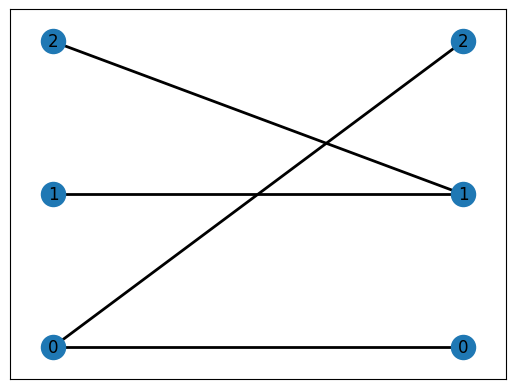

In [137]:
plot_weighted_bipartite(W, with_weights=False)

In [138]:
row_ind, col_ind = linear_sum_assignment(W, maximize=True)
matching = list(zip(row_ind, col_ind))
matching

[(np.int64(0), np.int64(0)),
 (np.int64(1), np.int64(1)),
 (np.int64(2), np.int64(2))]

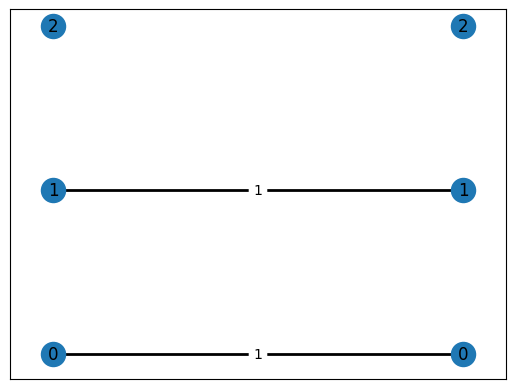

In [139]:
plot_weighted_matching(matching, W)

In [141]:
print(f'Matching size:{np.sum(W[row_ind,col_ind])}')
print(f'Number of elements in row_ind:{len(row_ind)}')

Matching size:2
Number of elements in row_ind:3


#### The matching actually contains "non-existing" edges (2-2 has weight=0).
#### linear_sum_assignment actually looks for a **complete matching**,
#### that is a matching whihch covers all nodes on one side of the graph.
#### so it matches 2-2 even if youse set $w_{(2,2)}=0$
#### by default (maximize=False), it is supposed to be used to solve the minimization problem with postive costs

### General balanced problem

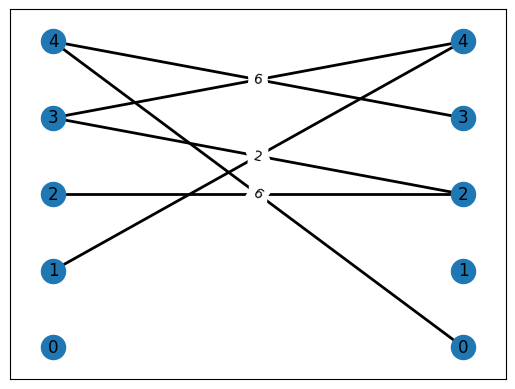

array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 2],
       [0, 0, 3, 0, 0],
       [0, 0, 2, 0, 6],
       [6, 0, 0, 6, 0]], dtype=int32)

In [68]:
np.random.seed(17)
W = np.random.randint(low=1,high=7,size=(5,5))
mask = np.random.binomial(n=1, size=W.shape, p=0.3)
W = W*mask
plot_weighted_bipartite(W)
plt.show()
W

Matching:[(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(2)), (np.int64(3), np.int64(4)), (np.int64(4), np.int64(3))]
Value: 15


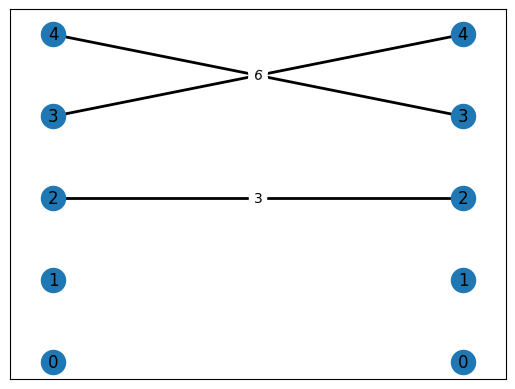

In [69]:
row_ind, col_ind = linear_sum_assignment(W, maximize=True)
matching = list(zip(row_ind, col_ind))
plot_weighted_matching(matching, W)
print(f'Matching:{matching}')
print(f'Value: {np.sum(W[row_ind,col_ind])}')

#### **Remark**: if there $w_{e} \ge 0$, the there always exist a maximum weighted matching that is also complete.
#### However, this may not be the case if at least an edge has negative weight.
#### Therefore linear_sum_assignment may return the wrong solution if you include edges with negative weights.

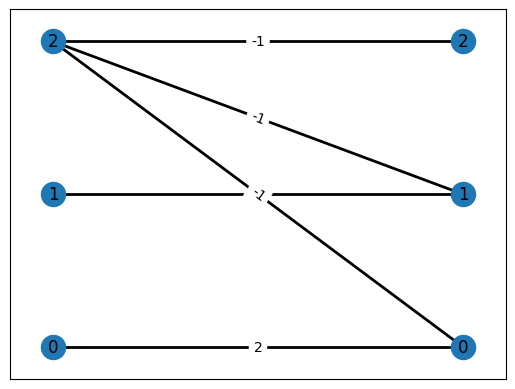

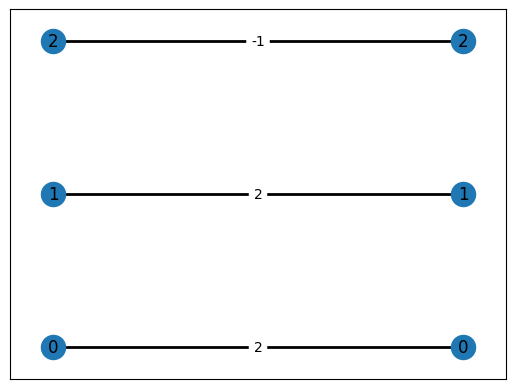

Matching:[(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(2))]
Value: 3


In [70]:
W = np.array([[2, 0, 0],
              [0, 2, 0],
              [-1, -1, -1]])
plot_weighted_bipartite(W, include_negative=True)
plt.show()

row_ind, col_ind = linear_sum_assignment(W, maximize=True)
matching = list(zip(row_ind, col_ind))
plot_weighted_matching(matching, W, with_non_positive=True)
plt.show()
print(f'Matching:{matching}')
print(f'Value: {np.sum(W[row_ind,col_ind])}')

### Non balanced matching

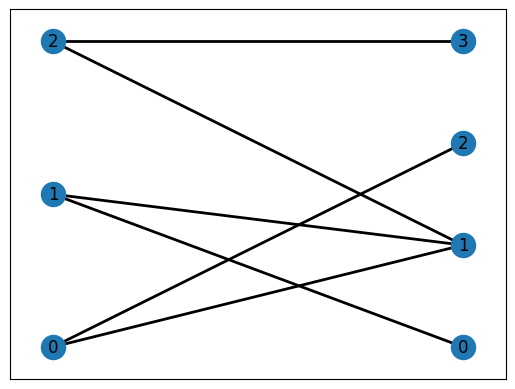

In [71]:
W = np.array([[0,1,1,0],
              [1,1,0,0],
              [0,1,0,1]])
plot_weighted_bipartite(W, with_weights=False)

Value: 3


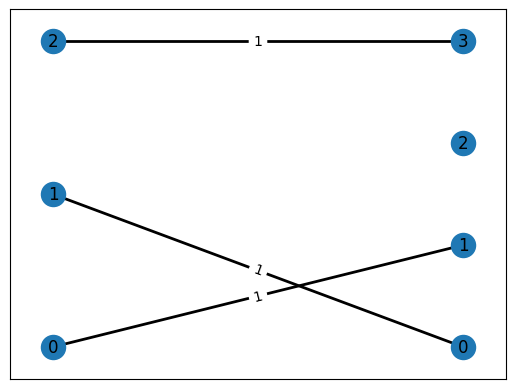

In [72]:
row_ind, col_ind = linear_sum_assignment(W, maximize=True)
matching = list(zip(row_ind, col_ind))
plot_weighted_matching(matching, W)
print(f'Value: {np.sum(W[row_ind,col_ind])}')

#### Most algorithms are designed for a balanced problem ($|S|=|Q|$)
#### You can balance the problem by adding dummy nodes

array([[0., 1., 1., 0.],
       [1., 1., 0., 0.],
       [0., 1., 0., 1.],
       [0., 0., 0., 0.]])

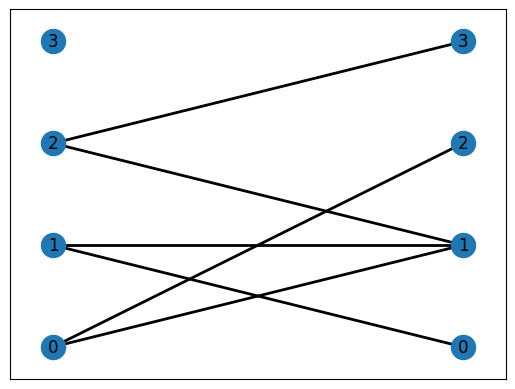

In [73]:
to_add = np.zeros((W.shape[1] - W.shape[0], W.shape[1]))
W_balanced = np.concatenate([W,to_add],axis=0)
plot_weighted_bipartite(W_balanced, with_weights=False)
W_balanced 

## Combinatorial bandits with matching constraint

#### We are given a bipartite graph
- #### Each edge $e$ is an arm with reward distribution $D_e$, $\mu_e \coloneqq \mathbb{E}[D_e]$ 
- #### At each round we can play a set of arms (super arm) $M_t=A_t$
- #### The super arm must satisfy some constraint, in this case it must be a matching
- #### We collect $r_t = \sum_{e \in M_t} r_{t,e}$ where $r_{t,e} \sim D_e$
- #### **Semi-bandit feedback**: we observe the contribution $r_{t,e}$ of each arm (edge) in the superarm (Matching)

#### We consider a bernoulli-enviroment: $w_{i,j} = \mu_{(i,j)}$ is the probability that worker $i$ completes tasks j.

In [144]:
class BernoulliMatchingEnv:
    def __init__(self, W, T):
        self.W = W
        # we can generate the realization in advance
        self.realizations = np.zeros((T,W.shape[0],W.shape[1]))
        for (i,j), p in np.ndenumerate(W):
            self.realizations[:,i,j] = np.random.binomial(n=1,p=p, size=T)
        self.t = 0
    
    def round(self, matching):
        # mathcing is a list of tuples (edges)
        # obs: the implementation is a bit inefficient
        # because we convert from two list to single list and then to double lists again,
        # but the single list of pairs is the most "intuitive" representation
        agents, tasks = list(zip(*matching))
        W_t = self.realizations[self.t]
        rewards = W_t[agents,tasks]
        self.t += 1
        return rewards # list of rewards (one for each edge of matching)


#### Notice that representing the super arm as a list of edges is natural, but it is not the most compact or efficient representation.

In [145]:
W = np.array([[0.1,0.3,0.7,0.1],
              [0.7,0.8,0.2,0.3],
              [0.5,0.7,0.1,0.9],
              [0.8,0.2,0.8,0.7]])
env = BernoulliMatchingEnv(W, 10)
super_arm = [[0,0],[1,1],[2,2],[3,3]]
rewards = env.round(super_arm)
rewards

array([0., 1., 0., 1.])

## Combinatorial UCB
- #### build an UCB for each arm
- #### the UCB of a superarm is the sum of the UCBs of its components
- #### play the super arm with the highest UCB


In [76]:
# We assume that every agent can complete every task (all edges exist)
class UCBMatchingAgent:
    def __init__(self, n_workers, n_tasks, T):
        self.W_avg = np.zeros((n_workers,n_tasks))
        self.N_pulls = np.zeros((n_workers,n_tasks))
        self.T = T # not strictly necessary, you can use the anytime version of UCB
        self.t = 0
        self.A_t = None
        self.rows_t = None
        self.cols_t = None
    
    def pull_arm(self):
        # if an arm is unexplored, then the UCB is a large value
        W = np.zeros(self.W_avg.shape, dtype=float)
        large_value = (1 + np.sqrt(2*np.log(self.T)/1))*10
        W[self.N_pulls==0] = large_value
        mask = self.N_pulls>0
        W[mask] = self.W_avg[mask] + np.sqrt(2*np.log(self.T)/self.N_pulls[mask])
        self.rows_t, self.cols_t = linear_sum_assignment(W, maximize=True)
        self.A_t = list(zip(self.rows_t, self.cols_t))
        return self.A_t

    def update(self, rewards):
        self.N_pulls[self.rows_t, self.cols_t] += 1
        self.W_avg[self.rows_t, self.cols_t] += (rewards - self.W_avg[self.rows_t, self.cols_t])/self.N_pulls[self.rows_t, self.cols_t]
        self.t += 1

#### First we test it on a non-combinatorial setting

In [77]:
W = np.array([[0.1,0.5,0.7,0.3]]) # a superarm is a single arm
clairvoyant_rows, clairvoyant_cols = linear_sum_assignment(W, maximize=True)
clairvoyant_matching = list(zip(clairvoyant_rows,clairvoyant_cols))
expected_clairvoyant_reward = np.sum(W[clairvoyant_rows, clairvoyant_cols])

T = 2000

regret_per_trial = []
pulls_per_trial = []
n_trials = 20

np.random.seed(32)
for _ in range(n_trials):
    env = BernoulliMatchingEnv(W, T)
    agent = UCBMatchingAgent(W.shape[0], W.shape[1], T)

    agent_rewards = np.array([])
    agent_pulls = np.zeros(W.shape[1])

    for t in range(T):
        A_t = agent.pull_arm()
        rewards_t = env.round(A_t)
        agent.update(rewards_t)

        agent_rewards = np.append(agent_rewards, np.sum(rewards_t))
        agent_pulls[A_t[0][1]] += 1

    cumulative_regret = np.cumsum(expected_clairvoyant_reward-agent_rewards)
    regret_per_trial.append(cumulative_regret)
    pulls_per_trial.append(agent_pulls)

regret_per_trial = np.array(regret_per_trial)
pulls_per_trial = np.array(pulls_per_trial)

avg_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

avg_pulls = pulls_per_trial.mean(axis=0)

In [78]:
avg_pulls

array([  30.85,  188.85, 1716.45,   63.85])

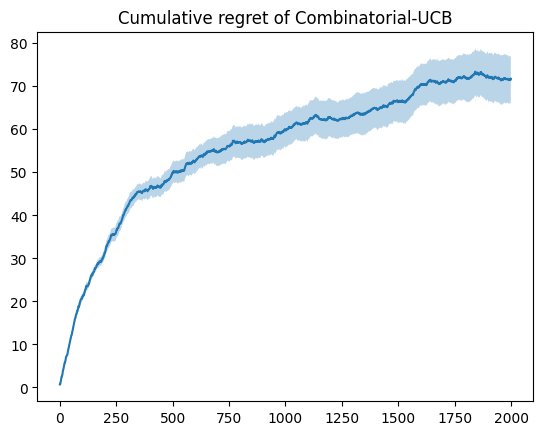

In [79]:
plt.plot(np.arange(T), avg_regret, label='Average Regret')
plt.title('Cumulative regret of Combinatorial-UCB')
plt.fill_between(np.arange(T),
                avg_regret-regret_sd/np.sqrt(n_trials),
                avg_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.show()

#### It should be equivalent to UCB1 for MABs

In [80]:
class UCB1Agent():
    def __init__(self, K, T, range=1):
        self.K = K
        self.T = T
        self.range = range
        self.a_t = None
        self.average_rewards = np.zeros(K)
        self.N_pulls = np.zeros(K)
        self.t = 0
    
    def pull_arm(self):
        if self.t < self.K:
            self.a_t = self.t 
        else:
            ucbs = self.average_rewards + self.range*np.sqrt(2*np.log(self.T)/self.N_pulls)
            self.a_t = np.argmax(ucbs)
        return self.a_t
    
    def update(self, r_t):
        self.N_pulls[self.a_t] += 1
        self.average_rewards[self.a_t] += (r_t - self.average_rewards[self.a_t])/self.N_pulls[self.a_t]
        self.t += 1

In [81]:
W = np.array([[0.1,0.5,0.7,0.3]]) # a superarm is a single arm
clairvoyant_rows, clairvoyant_cols = linear_sum_assignment(W, maximize=True)
clairvoyant_matching = list(zip(clairvoyant_rows,clairvoyant_cols))
expected_clairvoyant_reward = np.sum(W[clairvoyant_rows, clairvoyant_cols])

T = 2000

regret_per_trial = []
pulls_per_trial = []
n_trials = 20

np.random.seed(32)
for _ in range(n_trials):
    env = BernoulliMatchingEnv(W, T)
    agent = UCB1Agent(W.shape[1], T)

    agent_rewards = np.array([])
    agent_pulls = np.zeros(W.shape[1])

    for t in range(T):
        a_t = agent.pull_arm()
        A_t = [(0, a_t)]
        rewards_t = env.round(A_t)
        r_t = rewards_t[0]
        agent.update(r_t)

        agent_rewards = np.append(agent_rewards, np.sum(rewards_t))
        agent_pulls[A_t[0][1]] += 1

    cumulative_regret = np.cumsum(expected_clairvoyant_reward-agent_rewards)
    regret_per_trial.append(cumulative_regret)
    pulls_per_trial.append(agent_pulls)

regret_per_trial = np.array(regret_per_trial)
pulls_per_trial = np.array(pulls_per_trial)

avg_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

avg_pulls = pulls_per_trial.mean(axis=0)

In [82]:
avg_pulls

array([  30.85,  188.85, 1716.45,   63.85])

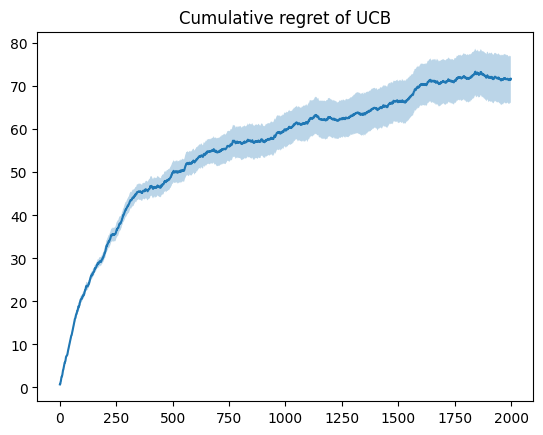

In [83]:
plt.plot(np.arange(T), avg_regret, label='Average Regret')
plt.title('Cumulative regret of UCB')
plt.fill_between(np.arange(T),
                avg_regret-regret_sd/np.sqrt(n_trials),
                avg_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.show()

### Now a combinatorial setting

In [84]:
W = np.array([[0.1,0.3,0.7,0.1],
              [0.3,0.8,0.2,0.3],
              [0.5,0.7,0.1,0.9],
              [0.8,0.2,0.5,0.7]])
clairvoyant_rows, clairvoyant_cols = linear_sum_assignment(W, maximize=True)
clairvoyant_matching = list(zip(clairvoyant_rows,clairvoyant_cols))
expected_clairvoyant_reward = np.sum(W[clairvoyant_rows, clairvoyant_cols])

T = 6000 

regret_per_trial = []
n_trials = 20

np.random.seed(32)
for _ in range(n_trials):
    env = BernoulliMatchingEnv(W, T)
    agent = UCBMatchingAgent(W.shape[0], W.shape[1], T)

    agent_rewards = []
    agent_superarms = []

    for t in range(T):
        A_t = agent.pull_arm()
        rewards_t = env.round(A_t)
        agent.update(rewards_t)

        agent_rewards.append(np.sum(rewards_t))
        agent_superarms.append(A_t)

    agent_rewards = np.array(agent_rewards)
    cumulative_regret = np.cumsum(expected_clairvoyant_reward-agent_rewards)
    regret_per_trial.append(cumulative_regret)

regret_per_trial = np.array(regret_per_trial)

avg_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

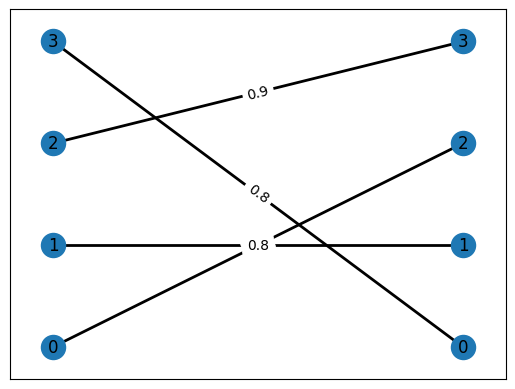

In [85]:
plot_weighted_matching(clairvoyant_matching, W)

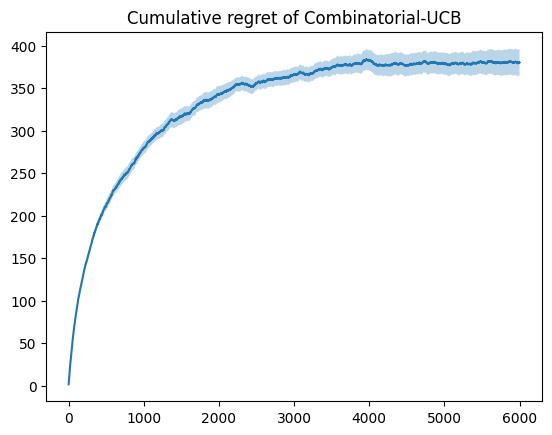

In [86]:
plt.plot(np.arange(T), avg_regret, label='Average Regret')
plt.title('Cumulative regret of Combinatorial-UCB')
plt.fill_between(np.arange(T),
                avg_regret-regret_sd/np.sqrt(n_trials),
                avg_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.show()

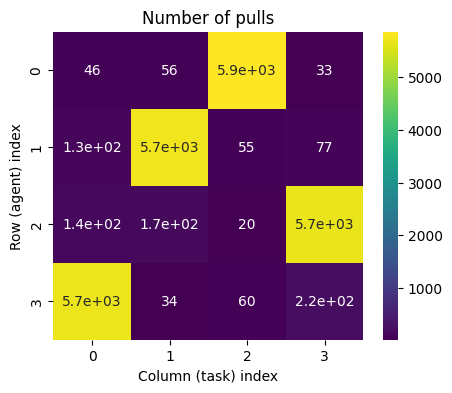

In [87]:
plt.figure(figsize=(5, 4))
sns.heatmap(agent.N_pulls, annot=True, cmap="viridis",
            xticklabels=np.arange(agent.N_pulls.shape[1]),
            yticklabels=np.arange(agent.N_pulls.shape[0]))

plt.xlabel("Column (task) index")
plt.ylabel("Row (agent) index")
plt.title("Number of pulls")
plt.show()

## Combinatorial TS
- #### Keep a Beta distribution for each arm
- #### At each $t$ draw a sample $\theta_{a,t}$ for every arm $a$
- #### Play $A_t = \arg\max_A \sum_{a \in A}\theta_{a,t}$
- #### Update the posteriors of the played arms

In [88]:
# for simplicty, we assume that every agent can complete every task (all edges exist)
class TSMatchingAgent:
    def __init__(self, n_workers, n_tasks):
        self.alpha, self.beta = np.ones((n_workers,n_tasks)), np.ones((n_workers,n_tasks))
        self.A_t = None

    def pull_arm(self):
        theta = np.random.beta(self.alpha, self.beta) # it's a matrix
        rows_t, cols_t = linear_sum_assignment(theta, maximize=True)
        self.A_t = list(zip(rows_t, cols_t))
        return self.A_t
    
    def update(self, rewards_t):
        for e, r_e in enumerate(rewards_t):
            row, column = self.A_t[e]
            self.alpha[row, column] += r_e
            self.beta[row, column] += 1-r_e

In [89]:
W = np.array([[0.1,0.3,0.7,0.1],
              [0.3,0.8,0.2,0.3],
              [0.5,0.7,0.1,0.9],
              [0.8,0.2,0.5,0.7]])
clairvoyant_rows, clairvoyant_cols = linear_sum_assignment(W, maximize=True)
clairvoyant_matching = list(zip(clairvoyant_rows,clairvoyant_cols))
expected_clairvoyant_reward = np.sum(W[clairvoyant_rows, clairvoyant_cols])

T = 6000

regret_per_trial = []
n_trials = 20

for seed in range(n_trials):
    np.random.seed(seed)
    env = BernoulliMatchingEnv(W, T)
    agent = TSMatchingAgent(W.shape[0], W.shape[1])

    agent_rewards = []
    agent_superarms = []

    for t in range(T):
        A_t = agent.pull_arm()
        rewards_t = env.round(A_t)
        agent.update(rewards_t)

        agent_rewards.append(np.sum(rewards_t))
        agent_superarms.append(A_t)

    agent_rewards = np.array(agent_rewards)
    cumulative_regret = np.cumsum(expected_clairvoyant_reward-agent_rewards)
    regret_per_trial.append(cumulative_regret)

regret_per_trial = np.array(regret_per_trial)

avg_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

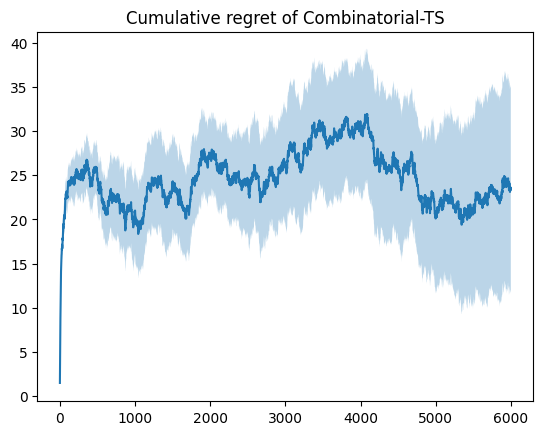

In [90]:
plt.plot(np.arange(T), avg_regret, label='Average Regret')
plt.title('Cumulative regret of Combinatorial-TS')
plt.fill_between(np.arange(T),
                avg_regret-regret_sd/np.sqrt(n_trials),
                avg_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.show()

#### As usual, UCB and TS have basically the same theoretical guarantees, but TS is empirically better

## Online Knapsack

- #### Capacity $C$
- #### Each arm $a$ has a **non-stochastic and known** size $s_a$
- #### We can plays superarms that do not exceed the capaicty
- #### Each arm is associated with a reward distribution

#### It can be seen as a problem with workers and tasks: 
- #### there are $C$ workers and they are all equivalent
- #### There are $K$ tasks, task $a$ requires $s_a$ workers to be executed and provides an unknown stochastic reward

#### **Remark**: this is **not** the budget constraint of the previous lectures

#### First we solve the offline problem (clairvoyant)

In [91]:
C = 10
s = np.array([3,  4, 5, 6, 7, 8])
mu = np.array([2, 3, 3, 5, 4, 7])
K = len(s)
mu/s, np.argsort(-mu/s)

(array([0.66666667, 0.75      , 0.6       , 0.83333333, 0.57142857,
        0.875     ]),
 array([5, 3, 1, 0, 2, 4]))

#### One possibility is to cast the problem as a MILP:
$$ \max_x \sum_a \mu_a x_a  \\ s.t. \sum_a s_a x_a \le C \\ \;\;\;\;\;\;\;\; x_a \in \{0,1\} \; \forall a$$

#### See also: https://docs.scipy.org/doc/scipy/tutorial/optimize.html#knapsack-problem-example



In [92]:
bounds = optimize.Bounds(0, 1)  # 0 <= x_a <= 1
integrality = np.ones(K)  # 1 in position a means that x_a is integer
constraints = optimize.LinearConstraint(A=s, lb=0, ub=C)
res = milp(c=-mu, constraints=constraints, integrality=integrality, bounds=bounds) #it minimizes
res.success, res.fun, res.x

(True, -8.0, array([0., 1., 0., 1., 0., 0.]))

In [93]:
# this is not the greedy solution:
mu/s, np.argsort(-mu/s)

(array([0.66666667, 0.75      , 0.6       , 0.83333333, 0.57142857,
        0.875     ]),
 array([5, 3, 1, 0, 2, 4]))

In [94]:
# let's write a resuable function
def solve_knapsack_milp(v, s, C):
    bounds = optimize.Bounds(0, 1)  # 0 <= x_a <= 1
    integrality = np.ones(len(v))  # 1 in position a means that x_a is integer
    constraints = optimize.LinearConstraint(A=s, lb=0, ub=C)
    res = milp(c=-v, constraints=constraints, integrality=integrality, bounds=bounds) #it minimizes
    return np.arange(len(v))[res.x > 0.5]
    # be careful: even if we impose the integrality constraint
    # milp can return something that is not exactly 1 (e.g. 1.000000007)
    # so do not use np.arange(len(v))[res.x == 1]
    # becasue sometimes it does not work

In [95]:
items = solve_knapsack_milp(mu, s, C)
print(f'items:{items}, value:{np.sum(mu[items])}')

items:[1 3], value:8


#### Another possibility is to use dynamic programming
#### Let $M(n,c)$ be the optimal value given capacity $c \le C$ and only the first $n$ items
#### $$M(n,c) = \max \{M(n-1,c), \mu_n +M(n-1,c-s_n)\} $$
#### with: 
- #### $M(n-1,c) = 0$ if $n-1 \le 0$ and $c \ge 0$
- #### $M(n-1,c-s_n) = -\infty$ if $c-s_n <0$

In [96]:
def solve_knapsack_dynamic(v, s, C):
    M = np.zeros((len(s),C+1)) # optimal values
    A = np.zeros((len(s),C+1)) # whether item n is added or not
    for n in range(len(s)):
        for c in range(C+1):
            M[n,c], A[n,c] = solve_knapsack_cell(v, s, n, c, M)
    
    items = []
    c = C
    for n in range(len(v)-1, -1, -1):
        if A[n,c] == 1:
            items.append(n)
            c = c - s[n]
    return items         

def solve_knapsack_cell(v, s, n, c, M):
    value_no_n = M[n-1,c] if n > 0 else 0 
    if s[n] > c:
        return value_no_n, 0
    value_with_n = v[n] + M[n-1, c-s[n]] if n>0 else v[n]
    if value_no_n > value_with_n:
        return value_no_n, 0
    return value_with_n, 1

#### We can also write a more efficient version.
#### However, the prblem is NP-Hard. For large instances we can approximate (it admits an FPTAS).

In [97]:
def solve_knapsack_efficient(v, s, C):
    n = len(v)
    
    dp = [0] * (C + 1)
    parent = [-1] * (C + 1)   # which item was used
    prev_c = [-1] * (C + 1)   # previous capacity

    for i in range(n):
        for c in range(C, s[i] - 1, -1):
            candidate = v[i] + dp[c - s[i]]
            if candidate > dp[c]:
                dp[c] = candidate
                parent[c] = i
                prev_c[c] = c - s[i]

    # reconstruct solution
    items = []
    c = C
    while c >= 0 and parent[c] != -1:
        i = parent[c]
        items.append(i)
        c = prev_c[c]

    return items[::-1]

In [98]:
items = solve_knapsack_dynamic(mu, s, C)
print(f'items:{items}, value:{np.sum(mu[items])}')

items:[3, 1], value:8


In [99]:
items = solve_knapsack_efficient(mu, s, C)
print(f'items:{items}, value:{np.sum(mu[items])}')

items:[1, 3], value:8


#### Now the online learning problem

In [100]:
class GaussianKnapsackEnv:
    def __init__(self, mu, s, T):
        self.mu = mu
        self.s = s
        # we can generate the realization in advance
        self.rewards = np.random.normal(mu, 1, size=(T,len(mu)))
        self.t = 0
    
    def round(self, A_t):
        r_t = self.rewards[self.t,A_t]
        self.t += 1
        return r_t

In [101]:
env = GaussianKnapsackEnv(mu, s, 3000)
env.round([0,3])

array([3.76550087, 5.9903056 ])

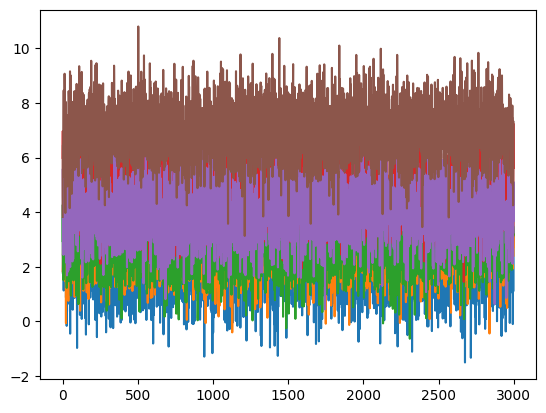

In [102]:
for a in range(len(mu)):
    plt.plot(env.rewards[:,a])

In [146]:
class UCBKnapsackAgent:
    def __init__(self, s, C, T, solver, sigma=1):
        self.avgs = np.zeros(len(s))
        self.N_pulls = np.zeros(len(s))
        self.K = len(s)
        self.s = s
        self.C = C
        self.T = T # not strictly necessary, you can use the anytime version of UCB
        self.solver = solver
        self.sigma = sigma
        self.t = 0
        # logging
        self.A_t = None
    
    def pull_arm(self):
        if np.min(self.N_pulls) == 0:
            # dummy knapsack problem to pull non-pulled arms
            values = np.ones(self.K)
            sizes = np.copy(self.s)
            sizes[self.N_pulls > 0] = self.C + 1
        else:
            values = self.avgs + self.sigma*np.sqrt(2*np.log(self.T)/self.N_pulls) #UCBs
            sizes = self.s
        self.A_t = self.solver(values, sizes, self.C)
        return self.A_t

    def update(self, rewards):
        self.N_pulls[self.A_t] += 1
        self.avgs[self.A_t] += (rewards - self.avgs[self.A_t])/self.N_pulls[self.A_t]
        self.t += 1

In [147]:
C = 10
s = np.array([3,  4, 5, 6, 7, 8])
mu = np.array([2, 3, 3, 5, 4, 7])
clairvoyant_superarm = solve_knapsack_efficient(mu, s, C)
expected_clairvoyant_reward = np.sum(mu[clairvoyant_superarm])
print(f'Clayrvoyant solution:{clairvoyant_superarm}, value:{expected_clairvoyant_reward} space:{np.sum(s[clairvoyant_superarm])}')

T = 10000

regret_per_trial = []
stabilized_regret_for_trial = []
n_trials = 30
# n_trials = 100

for seed in range(n_trials):
    np.random.seed(seed)
    env = GaussianKnapsackEnv(mu, s, T)
    agent = UCBKnapsackAgent(s, C, T, solve_knapsack_efficient)

    agent_rewards = []
    agent_mean_rewards = []

    for t in range(T):
        A_t = agent.pull_arm()
        rewards_t = env.round(A_t)
        agent.update(rewards_t)

        agent_rewards.append(np.sum(rewards_t))
        agent_mean_rewards.append(np.sum(mu[A_t]))

    agent_rewards = np.array(agent_rewards)
    cumulative_regret = np.cumsum(expected_clairvoyant_reward-agent_rewards)
    regret_per_trial.append(cumulative_regret)
    agent_mean_rewards = np.array(agent_mean_rewards)
    stabilized_regret_for_trial.append(np.cumsum(expected_clairvoyant_reward-agent_mean_rewards))

regret_per_trial = np.array(regret_per_trial)
avg_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

stabilized_regret_for_trial = np.array(stabilized_regret_for_trial)
avg_stabilized_regret = stabilized_regret_for_trial.mean(axis=0)
stabilized_regret_std = stabilized_regret_for_trial.std(axis=0)

Clayrvoyant solution:[1, 3], value:8 space:10


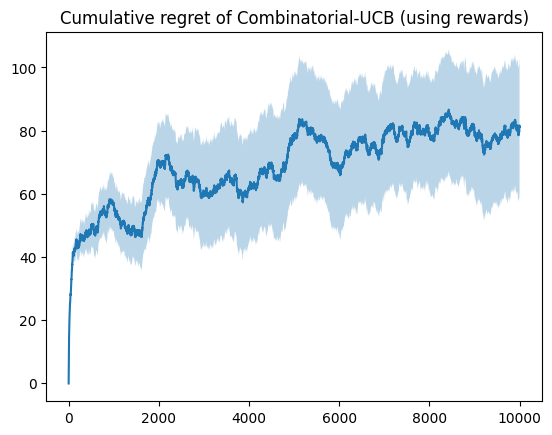

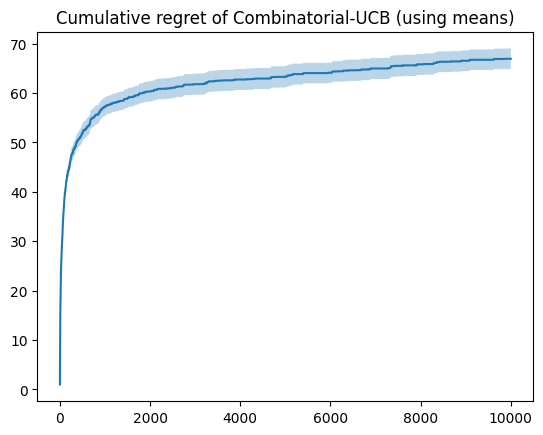

In [148]:
plt.plot(np.arange(T), avg_regret, label='Average Regret')
plt.title('Cumulative regret of Combinatorial-UCB (using rewards)')
plt.fill_between(np.arange(T),
                avg_regret-regret_sd/np.sqrt(n_trials),
                avg_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.show()

plt.plot(np.arange(T), avg_stabilized_regret, label='Average Regret')
plt.title('Cumulative regret of Combinatorial-UCB (using means)')
plt.fill_between(np.arange(T),
                avg_stabilized_regret-stabilized_regret_std/np.sqrt(n_trials),
                avg_stabilized_regret+stabilized_regret_std/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.show()

#### Another example

In [149]:
class BernoulliKnapsackEnv:
    def __init__(self, mu, s, T):
        self.mu = mu
        self.s = s
        # we can generate the realization in advance
        self.rewards = np.random.binomial(n=1,p=mu, size=(T,len(mu)))
        self.t = 0
    
    def round(self, A_t):
        r_t = self.rewards[t,A_t]
        self.t += 1
        return r_t

In [150]:
C = 9
s = np.array([3,  4, 5, 6, 7, 8])
mu = np.array([0.2,0.3,0.4,0.6,0.62,0.65])
clairvoyant_superarm = solve_knapsack_efficient(mu, s, C)
expected_clairvoyant_reward = np.sum(mu[clairvoyant_superarm])
print(f'Clayrvoyant solution:{clairvoyant_superarm}, value:{expected_clairvoyant_reward} space:{np.sum(s[clairvoyant_superarm])}')

T = 10000

regret_per_trial = []
n_trials = 10
# n_trials = 100

for seed in range(n_trials):
    np.random.seed(seed)
    env = BernoulliKnapsackEnv(mu, s, T)
    agent = UCBKnapsackAgent(s, C, T, solve_knapsack_efficient)

    agent_rewards = []

    for t in range(T):
        A_t = agent.pull_arm()
        rewards_t = env.round(A_t)
        agent.update(rewards_t)

        # agent_rewards.append(np.sum(rewards_t))
        agent_rewards.append(np.sum(mu[A_t]))

    agent_rewards = np.array(agent_rewards)
    cumulative_regret = np.cumsum(expected_clairvoyant_reward-agent_rewards)
    regret_per_trial.append(cumulative_regret)

regret_per_trial = np.array(regret_per_trial)

avg_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

Clayrvoyant solution:[0, 3], value:0.8 space:9


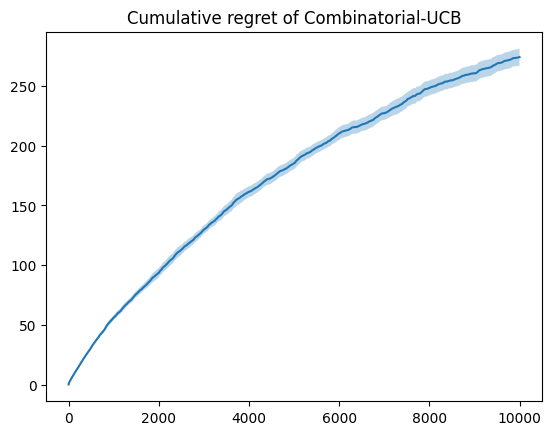

In [151]:
plt.plot(np.arange(T), avg_regret, label='Average Regret')
plt.title('Cumulative regret of Combinatorial-UCB')
plt.fill_between(np.arange(T),
                avg_regret-regret_sd/np.sqrt(n_trials),
                avg_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.show()

In [152]:
# let's write a resuable function
def second_optimal_knapsack(v, s, C, opt_value, epsilon=0.00001):
    bounds = optimize.Bounds(0, 1)  # 0 <= x_a <= 1
    integrality = np.ones(len(v))  # 1 in position a means that x_a is integer
    constraints = optimize.LinearConstraint(A=s, lb=0, ub=C)
    constraints = optimize.LinearConstraint(A=v, lb=0, ub=opt_value-epsilon)
    res = milp(c=-v, constraints=constraints, integrality=integrality, bounds=bounds) #it minimizes
    return np.arange(len(v))[res.x > 0.5]

In [153]:
second_optimal = second_optimal_knapsack(mu,s,C,expected_clairvoyant_reward,epsilon=1/(2*T))
second_optimal_value = np.sum(mu[second_optimal])
print(f'Optiaml solution:{clairvoyant_superarm}, optimal value:{expected_clairvoyant_reward}')
print(f'Second solution:{second_optimal}, second value:{second_optimal_value}')

Optiaml solution:[0, 3], optimal value:0.8
Second solution:[1 2], second value:0.7


#### Notice that the two sets are disoint. 
#### There are also arms with mean 0.62 and 0.65 that can only be pulled alone
#### Every other arm is suboptimal (even for exploration)
#### Hence this problem is more difficult than a MAB with two Bernoulli variables and $p=[0.8,0.7,0.65,0.62]$
#### Let's run UCB1 on that MAB instance

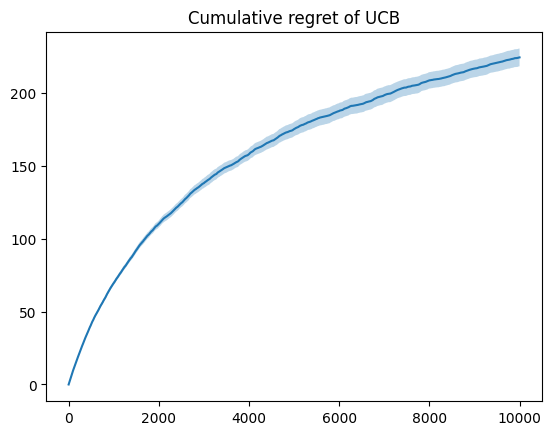

In [154]:
# We use a matching environment to simulate a MAB
W = np.array([[0.8,0.7,0.65,0.62]]) # a superarm is a single arm
clairvoyant_rows, clairvoyant_cols = linear_sum_assignment(W, maximize=True)
clairvoyant_matching = list(zip(clairvoyant_rows,clairvoyant_cols))
expected_clairvoyant_reward = np.sum(W[clairvoyant_rows, clairvoyant_cols])

T = 10000

regret_per_trial = []
pulls_per_trial = []
n_trials = 30

for seed in range(n_trials):
    np.random.seed(seed)
    env = BernoulliMatchingEnv(W, T)
    agent = UCB1Agent(W.shape[1], T)

    agent_rewards = []
    agent_pulls = np.zeros(W.shape[1])

    for t in range(T):
        a_t = agent.pull_arm()
        A_t = [(0, a_t)]
        rewards_t = env.round(A_t)
        r_t = rewards_t[0]
        agent.update(r_t)

        # agent_rewards.append(np.sum(rewards_t))
        agent_rewards.append(W[0,a_t])
        agent_pulls[A_t[0][1]] += 1

    cumulative_regret = np.cumsum(expected_clairvoyant_reward-agent_rewards)
    regret_per_trial.append(cumulative_regret)
    pulls_per_trial.append(agent_pulls)

regret_per_trial = np.array(regret_per_trial)
pulls_per_trial = np.array(pulls_per_trial)

avg_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

avg_pulls = pulls_per_trial.mean(axis=0)

plt.plot(np.arange(T), avg_regret, label='Average Regret')
plt.title('Cumulative regret of UCB')
plt.fill_between(np.arange(T),
                avg_regret-regret_sd/np.sqrt(n_trials),
                avg_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.show()

#### It is similar to the regret in the combinatorial setting.
#### We can conclude that our result in the combinatorial setting can be expected.

## Online shortest path

- #### Given weighted graph G=(V,E), start node $a=1$ and end node $b=|V|$
- #### Edges are arms with stocastic cost, $\mathbb{E}[c_{i,j}] = w_{i,j}$
- #### A superarm is a path from $a$ to $b$
- #### Baseline: path with minimum expected cost

#### **Remark**: here we minimize a cost

In [112]:
# example from slide 19
W = np.array([[0,9,np.inf,2,np.inf],
              [9,0,4,3,1],
              [np.inf,4,0,7,5],
              [2,3,7,0,2],
              [np.inf,1,5,2,0]])
W

array([[ 0.,  9., inf,  2., inf],
       [ 9.,  0.,  4.,  3.,  1.],
       [inf,  4.,  0.,  7.,  5.],
       [ 2.,  3.,  7.,  0.,  2.],
       [inf,  1.,  5.,  2.,  0.]])

In [113]:
dist_matrix, predecessors = shortest_path(csgraph=W, directed=False, indices=0, return_predecessors=True)
dist_matrix, predecessors

(array([0., 5., 9., 2., 4.]),
 array([-9999,     3,     3,     0,     3], dtype=int32))

In [114]:
# we represent the path as a list of edges
# it is not the most comapct or efficient representation
# but it explicitly models the superarm as a set of arms
path = []
current = W.shape[0]-1
while current > 0:
    edge = (predecessors[current], current)
    path.append(edge)
    current = predecessors[current]
path = list(reversed(path))

rows, columns = list(zip(*path))
expected_cost = np.sum(W[rows, columns])
print(f'Path:{path}, expected cost:{expected_cost}')

Path:[(np.int32(0), np.int32(3)), (np.int32(3), 4)], expected cost:4.0


In [115]:
def compute_shortest_path(W):
    # depending on the auto-chosen algorithm
    # shortest_path may treat even explicit zeros as non-existing edges
    # so we make them small, but non-zero
    W = np.copy(W)
    W[W==0] += 0.0001
    dist_matrix, predecessors = shortest_path(csgraph=W, directed=False, indices=0, return_predecessors=True)
    path = []
    current = W.shape[0]-1
    while current > 0:
        edge = (predecessors[current], current)
        path.append(edge)
        current = predecessors[current]
    path = list(reversed(path))

    return path

In [116]:
class GaussianPathEnv:
    def __init__(self, W, T, sigma=1):
        self.W = W
        # we can generate the realization in advance
        self.costs = np.zeros((T,W.shape[0],W.shape[1]))
        for (i,j), w in np.ndenumerate(W):
            self.costs[:,i,j] = np.random.normal(w, sigma, size=T)
            self.costs[self.costs[:,i,j]<=0,i,j] = 0
        self.t = 0
    
    def round(self, path):
        # mathcing is a list of tuples (edges)
        # obs: the implementation is a bit inefficient
        # because we convert from two list to single list and then to double lists again,
        # but the single list of pairs is the most "intuitive" representation
        rows, columns = list(zip(*path))
        W_t = self.costs[self.t,:,:]
        costs = W_t[rows, columns]
        self.t += 1
        return costs # list of rewards (one for each edge of matching)

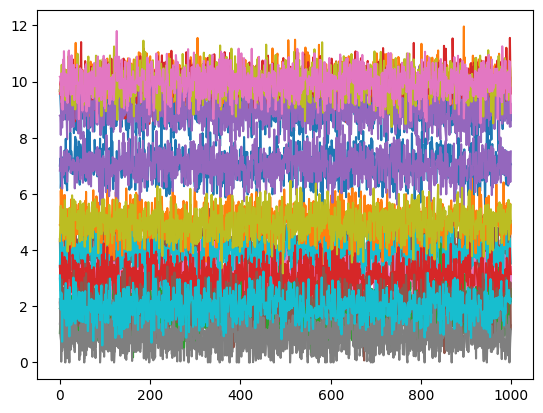

In [ ]:
# obs: the agent knows in advance non-existing edges
# if the agent doesn't know them and they have infinite cost, the regret is going to be infinite
W = np.array([[0,9,10,2,10],
              [9,0,4,3,1],
              [10,4,0,7,5],
              [2,3,7,0,2],
              [10,1,5,2,0]])

np.random.seed(42)
env = GaussianPathEnv(W, 1000, sigma=0.5)
for (i,j), w in np.ndenumerate(W):
    if i != j:
        plt.plot(env.costs[:,i,j])

In [118]:
env.round([(0,2),(2,3),(3,4)])

array([9.66241086, 7.00586818, 2.13255355])

In [119]:
class UCBPathAgent:
    def __init__(self, n_nodes, T, range=1):
        self.W_avg = np.zeros((n_nodes,n_nodes))
        self.N_pulls = np.zeros((n_nodes,n_nodes))
        self.T = T # not strictly necessary, you can use the anytime version of UCB
        self.range = range
        self.t = 0
        self.A_t = None
        self.rows_t = None
        self.cols_t = None
    
    def prepare_W(self, verbose=False):
        # playing each arm once in a few roudns is difficult
        # morevoer, if you know that reaching i takes a lot, you do not want to explore edges (i,j)
        # simple idea: use the minimum possible cost (0) for arms that have not been pulled
        non_pulled_mask = self.N_pulls == 0
        pulled_mask = self.N_pulls > 0
        W = np.copy(self.W_avg)
        W[pulled_mask] = self.W_avg[pulled_mask] - self.range*np.sqrt(2*np.log(self.T)/self.N_pulls[pulled_mask]) # use the LCBs (minimize cost)
        W[non_pulled_mask] = 0
        # we know that w_ii = 0
        for i in range(W.shape[0]):
            W[i,i] = 0
        # clip to zero to avoid negative cycles (LCBs could be negative in the first rounds)
        W[W<0] = 0
        if verbose:
            print(W, self.N_pulls)
        return W
    
    def pull_arm(self, verbose=False):
        W = self.prepare_W(verbose)
        self.A_t = compute_shortest_path(W)
        return self.A_t

    def update(self, costs):
        for index, edge in enumerate(self.A_t):
            i,j = edge
            self.N_pulls[i, j] += 1
            self.W_avg[i,j] += (costs[index] - self.W_avg[i,j])/self.N_pulls[i,j]
            # symmetry
            self.N_pulls[j, i] += self.N_pulls[i, j]
            self.W_avg[j, i] = self.W_avg[i, j]
        self.t += 1

In [127]:
W = np.array([[0,9,10,2,10],
              [9,0,4,3,1],
              [10,4,0,7,5],
              [2,3,7,0,2],
              [10,1,5,2,0]], dtype=float)
clairvoyant_superarm = compute_shortest_path(W)
rows, columns = list(zip(*clairvoyant_superarm))
expected_clairvoyant_cost = np.sum(W[rows, columns])

T = 3000

regret_per_trial = []
n_trials = 10

# np.random.seed(32)
for seed in range(n_trials):
    np.random.seed(seed)
    env = GaussianPathEnv(W, T, sigma=0.5)
    agent = UCBPathAgent(W.shape[0], T, 0.5)

    agent_costs = []

    for t in range(T):
        A_t = agent.pull_arm()
        costs_t = env.round(A_t)
        agent.update(costs_t)

        # agent_costs.append(np.sum(costs_t))
        rows, columns = list(zip(*A_t))
        expected_agent_cost = np.sum(W[rows, columns])
        # print(A_t,expected_agent_cost)
        agent_costs.append(expected_agent_cost)

    agent_costs = np.array(agent_costs)
    cumulative_regret = np.cumsum(agent_costs-expected_clairvoyant_cost)
    regret_per_trial.append(cumulative_regret)

regret_per_trial = np.array(regret_per_trial)

avg_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

In [128]:
W

array([[ 0.,  9., 10.,  2., 10.],
       [ 9.,  0.,  4.,  3.,  1.],
       [10.,  4.,  0.,  7.,  5.],
       [ 2.,  3.,  7.,  0.,  2.],
       [10.,  1.,  5.,  2.,  0.]])

In [129]:
clairvoyant_superarm, expected_clairvoyant_cost

([(np.int32(0), np.int32(3)), (np.int32(3), 4)], np.float64(4.0))

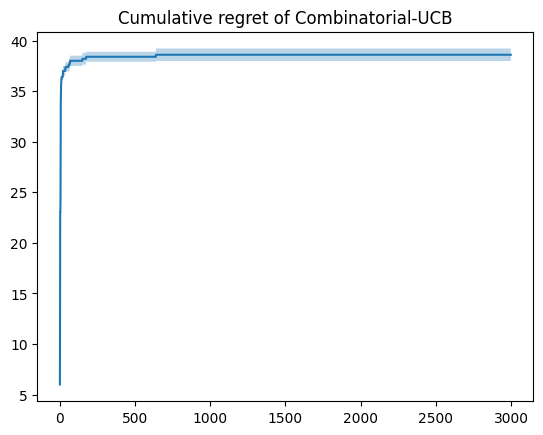

In [130]:
plt.plot(np.arange(T), avg_regret, label='Average Regret')
plt.title('Cumulative regret of Combinatorial-UCB')
plt.fill_between(np.arange(T),
                avg_regret-regret_sd/np.sqrt(n_trials),
                avg_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.show()

In [131]:
min(agent_costs)

np.float64(4.0)

#### If there is more noise and a more difficult instance:

In [125]:
W = np.array([[ 0, 9,10, 5,10],
              [ 9, 0, 4, 5, 4],
              [10, 4, 0, 7, 5],
              [ 5, 5, 7, 0, 4],
              [10, 4, 5, 4, 0]], dtype=float)
clairvoyant_superarm = compute_shortest_path(W)
rows, columns = list(zip(*clairvoyant_superarm))
expected_clairvoyant_cost = np.sum(W[rows, columns])
print('Clairvoyant path:',clairvoyant_superarm, ', cost:', expected_clairvoyant_cost)

T = 5000
sigma = 4

regret_per_trial = []
n_trials = 10

for seed in range(n_trials):
    np.random.seed(seed)
    env = GaussianPathEnv(W, T, sigma=4)
    agent = UCBPathAgent(W.shape[0], T, 4)

    agent_costs = []

    for t in range(T):
        A_t = agent.pull_arm()
        costs_t = env.round(A_t)
        agent.update(costs_t)

        # agent_costs.append(np.sum(costs_t))
        rows, columns = list(zip(*A_t))
        expected_agent_cost = np.sum(W[rows, columns])
        # print(A_t,expected_agent_cost)
        agent_costs.append(expected_agent_cost)

    agent_costs = np.array(agent_costs)
    cumulative_regret = np.cumsum(agent_costs-expected_clairvoyant_cost)
    regret_per_trial.append(cumulative_regret)

regret_per_trial = np.array(regret_per_trial)

avg_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

Clairvoyant path: [(np.int32(0), np.int32(3)), (np.int32(3), 4)] , cost: 9.0


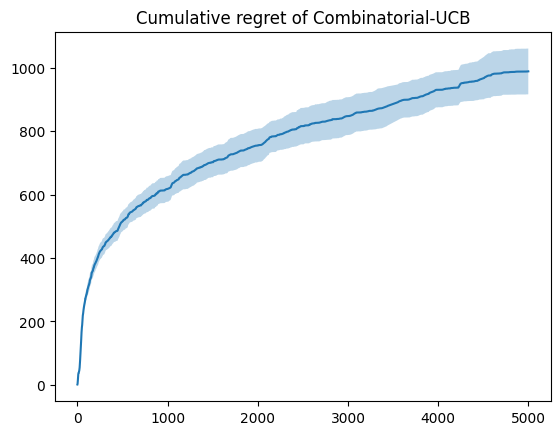

In [126]:
plt.plot(np.arange(T), avg_regret, label='Average Regret')
plt.title('Cumulative regret of Combinatorial-UCB')
plt.fill_between(np.arange(T),
                avg_regret-regret_sd/np.sqrt(n_trials),
                avg_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.show()